# 🧪LAB: Partial Least Squares Regression

In this lab, you will explore **Partial Least Squares (PLS) Regression**, a powerful technique for modeling relationships between high-dimensional, collinear predictors and a continuous outcome. You will begin with a **group discussion** after reading about the method. Next, you will become familiar with its implementation in `scikit-learn` by **recreating and reflecting on one of their tutorials**. Finally, you will apply PLS to a **real-world chemoinformatics dataset** that includes binary molecular fingerprints as predictors and a continuous permeability outcome for a set of chemical compounds.

PLS is particularly useful when the number of predictors is large and highly correlated, making traditional regression methods unstable or ineffective. You will also compare PLS with an alternative predictive model that also involves a dimensionality-reduction approach: **Penalized Principal Component Regression (PCR)**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

## 1. Reading & Group Discussion (10 Points) 

Carefully read **Sections 6.2 and 6.3** of the *An Introduction to Statistical Learning* book (Reference B). The first section introduces Principal Component Regression (PCR), which we already covered in a previous class. The second section, instead, introduces Partial Least Squares (PLS).

After reviewing the content, discuss with your group and then answer the following questions:

a. What is the key difference between Principal Component Regression (PCR) and Partial Least Squares (PLS) ?
As a group we talked about how PCR doesn't even look at Y when it's picking its components — it just grabs whatever directions in X have the most variance and calls it a day. PLS actually uses Y the whole time it's building components, so it's trying to find directions that both explain X and are useful for predicting Y. Basically PCR is "blind" to the response, PLS isn't.

b. Why might PCR fail to find directions that are useful for predicting the response `Y`? 
Because PCR is just chasing variance in X, there's nothing stopping it from picking a direction that has tons of spread but zero relationship to Y. And on the flip side, if the direction that actually matters for predicting Y happens to be a low-variance one, PCR could totally miss it or rank it low. It's kind of just lucky if the high-variance directions line up with what predicts Y — no guarantee.

c. In PLS, how is the first direction `Z₁` computed? 
We had to reread this part a couple times. Each predictor gets standardized first, then PLS runs a simple regression of Y on each predictor one at a time and uses those individual slope coefficients as the weights. So predictors that are more strongly correlated with Y on their own get more weight in Z₁. It's basically a weighted average of the X's, where the weights come straight from how well each X predicts Y by itself.

d. What are some similarities and differences between PLS and penalized regression? 
They are similar in that both are trying to fix the same problem: too many predictors, multicollinearity, overfitting, all that. And both are fine taking on a little more bias if it means cutting down variance by a lot. That's basically the shared motivation.They definitely go about it differently though. Ridge/lasso keep every single predictor in the model, they just shrink the coefficients down toward zero (and lasso will even zero some out completely), so you're still working with the original X variables the whole time. PLS does something else entirely, it builds a small number of new components that are combinations of the X's and fits the model using those instead. So it's compressing everything into fewer dimensions rather than just shrinking the coefficients on the original variables. They end up in a similar place (simpler model, less overfitting) but they get there through pretty different routes. 

YOUR TEXT HERE

## 2. Recreate, Explain, Experiment & Reflect (35 points)

Follow this tutorial on Partial Least Squares (PLS) from the official scikit-learn documentation:

📘 [scikit-learn: PLS regression example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Your goal is to **recreate the PLS portion of the tutorial in this notebook**, and make sure you understand what each part of the code is doing. This will give you the opportunity to build intuition for how PLS works. Be thorough in your answers and interpretations — this will help you when working with real data later in this lab assignment.

### a. Recreate
- Load the dataset used in the tutorial. Make sure to create a training/reporting partition.
- Fit a `PLSRegression` model with 1 component. 

In [123]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression

# imported all necessary libraries for PCA and PLS regression 

rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
pca = PCA(n_components=2).fit(X) #fits PCA to X and finds the principal components of the dataset
# imported the dataset from the tutorial and fitted the PCA model to the dataset 

y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2 
X_train, X_report, y_train, y_report = train_test_split(X, y, random_state=rng) #splits the dataset into training and testing sets 
pls = PLSRegression(n_components=1) #creates a PLS regression model with 1 component
pls.fit(X_train, y_train) #fits the PLS model to the training data

,n_components,1
,scale,True
,max_iter,500
,tol,1e-06
,copy,True


### b. Explain
For **every block of code**, add a markdown cell that explains:

- What is the goal of this step?
- Why is this important in a PLS regression pipeline?
- What does the output mean or tell us?

Block 1: 
The goal was to import the relevant libraries and functions needed to create the model. PLS regression requires NumPy, PCA, and train_test_split to create the data, separate the training and testing sets, and fit the final model. This does not produce an output. 


Block 2:
The goal of this step was to recreate the dataset from the tutorial. The dataset consists of 500 observations with two correlated features. This helps demonstrate the difference between PCA and PLS. X contains the 500 observations and two features. The fitted PCA model stores the two components and represents the variation in the dataset. 


Block 3: The goal was to create the target variable y and add noise. The second PCA component represents another direction in the data. y depends on this direction, and PLS uses this information about both directions and the target. The output is the target variable y, which contains a response value for each of the 500 observations.  


Block 4: The goal was to divide the dataset into training and testing data. The training data is used to estimate the PLS model, while the reporting data is used later to evaluate the model on observations it has never seen. X_train and y_train contain observations used to fit the model. X_report and y_report contain the remaining observations that can be used to evaluate the model's performance. 

Block 5: The goal of this step is to create a Partial Least Squares regression model using one component. Setting n_components = 1 forces the PLS model to utilize one component and see whether PLS can identify the single direction that is most useful for predicting y. The output is simply that the model has been created- no learning yet.


Block 6: 
The goal was to train the PLS regression model using X_train and y_train. PLS uses both the predictor and response variables to find a component in X that predicts y. After fitting, the pls object contains the learned PLS components, and the model can now transform new observations into the learned PLS components and make predictions for y.

### c. Experiment
Make the following changes:
- Change the number of components to **2 components** and fit again the model.
- Plot the **predicted vs. actual** response values on the reporting set.
- Report **R²** and **Mean Squared Error (MSE)** for your model
- On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.

R-squared: 0.6732047416473494
MSE: 0.21659109767291343


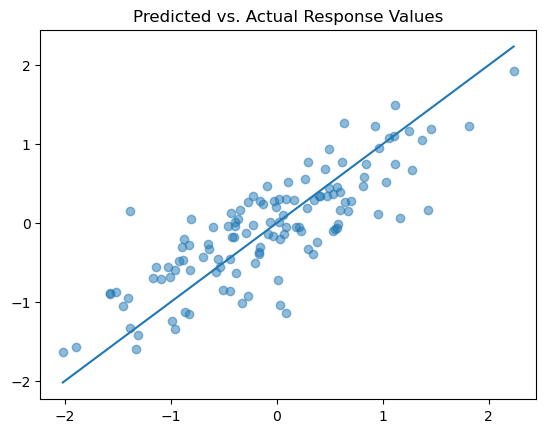

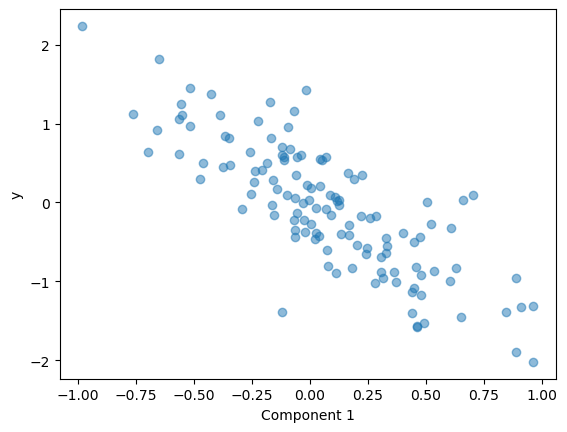

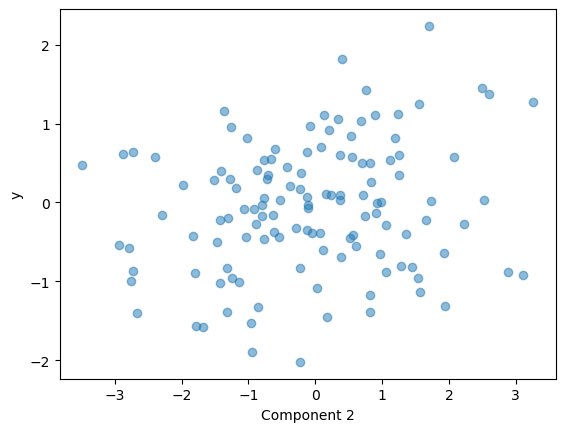

In [124]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

pls_2 = PLSRegression(n_components=2) # creates a PLS regression model with 2 components
pls_2.fit(X_train, y_train) # fits the PLS model to the training data
y_pred = pls_2.predict(X_report).ravel()
r2 = r2_score(y_report, y_pred) # calculates the R-squared value for the model's predictions
mse = mean_squared_error(y_report, y_pred) # calculates the mean squared error for the model's predictions  

print("R-squared:", r2)
print("MSE:", mse)

plt.scatter(y_report, y_pred, alpha=0.5) # creates a scatter plot of the actual vs predicted values
plt.plot([y_report.min(), y_report.max()],[y_report.min(), y_report.max()])
plt.title("Predicted vs. Actual Response Values")
plt.show()

X_components = pls_2.transform(X_report)
corr1 = np.corrcoef(X_components[:, 0], y_report)[0, 1] # calculates the correlation between component 1 and y
corr2 = np.corrcoef(X_components[:, 1], y_report)[0, 1] # calculates the correlation between component 2 and y

plt.scatter(X_components[:, 0], y_report, alpha=0.5) 
plt.xlabel("Component 1")
plt.ylabel("y")
plt.show()

plt.scatter(X_components[:, 1], y_report, alpha=0.5)
plt.xlabel("Component 2")
plt.ylabel("y")
plt.show()





### d. Reflect
Finally, answer these questions:

- What do the learned PLS components represent in your dataset?
- Did increasing the number of components improve performance?
- What makes PLS different from PCA?

1. The learned PLS components represent new combinations of the original features in X used to create y. Because PLS looks for directions in the data most related to the response variable, the first component captured most of the information most closely related to y, while the second component had a weaker relationship with y. 
2. Increasing the number of components improved the model performance as the R-squared value increased from .658 to about .673. This showed that the second component added some additional information, but the first component captured most of it. 
3. The main difference between PCA and PLS is that PCA is unsupervised while PLS is supervised. Unlike PCA, which does not look at any target, PLS uses both X and y to create components to find directions that may have lower variance but are still important for predicting the outcome. 


## 3. PLS on real data: Molecular Fingerprints and Permeability (50 points)

In this final part of the lab, you will apply PLS Regression to a real-world, high-dimensional dataset from pharmaceutical research.

The goal is to build a predictive model of compound permeability—a key property that determines a molecule’s ability to cross biological membranes such as the intestinal wall or the blood–brain barrier. Permeability is critical in drug development, as compounds that cannot reach their target tissues may ultimately fail despite promising initial results.

You will work with a dataset containing 165 compounds characterized by 1,107 binary molecular fingerprints, which indicate the presence or absence of specific chemical substructures. Your task is to use PLS to predict each compound's permeability and evaluate whether such a model could serve as a computational alternative to expensive, labor-intensive lab assays.

Here the link to the dataset: https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv

### a. Prepare data

- Load the dataset.
- Separate the molecular fingerprint variables (`X`) from the permeability values (`y`).
- Split the data into training and reporting sets (e.g., 70/30 split).

### b. Create a pipeline.

Create a pipeline that includes the following: 

- A variance thresholding step to remove near-constant binary features, since molecular fingerprints are typically sparse.
(Hint: you may want to check the `feature_selection` module in `scikit-learn`.)
- A standardization step.
- The Partial Least Squares Regression method.

### c. Optimize and train.

After you create the pipeline, you should optimize (using cross-validation) and train your pipeline. Your optimization should tune the number of PLS components. After training, report:

- The number of predictors remaining after the variance thresholding step
- The selected number of PLS components
- The cross-validated **R²** on the training set.


### d. Evaluate

- Use the best PLS model to predict permeability on the reporting set
- Report the reporting set R²

### e. Compare.

- Compare with the performance obtained using a penalized principal component regression. You may experiment with Lasso, Ridge or/and ElasticNet. Make sure to encapsulate this model into a pipeline and optimize it as well.


### f. Reflect

Discuss:
- Which model performed best?
- Would you trust any of your models enough to replace the permeability lab assay?
- What would be the trade-offs of doing so?

In [125]:
# YOUR ANSWERS FROM HERE (USE AS MANY CELLS AS NEEDED)

# Section A
#Imports
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

df = pd.read_csv("lab01_data.csv")
X = df.drop("permeability", axis = 1)
Y = df.loc[:,["permeability"]]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=rng)

In [126]:
# Section B
# Incorporates Scaling and standardizing the data, Variance Threshold, and Creating our PLS model itself and fitting it
pipe = Pipeline([('threshold', VarianceThreshold()), ('scaler', StandardScaler()), ('pls', PLSRegression(n_components=2))])
pipe.fit(X_train, Y_train)

,steps,"[('threshold', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,threshold,0.0
,copy,True
,with_mean,True
,with_std,True
,n_components,2
,scale,True
,max_iter,500


In [127]:
# Section C
param_grid_cv = {"pls__n_components" : range(1,11)}
bestSearch = GridSearchCV(pipe, param_grid_cv, cv=10)
bestSearch.fit(X_train, Y_train)
print(f"Number of predictions: {bestSearch.best_params_}")
print(f"Number of PLS Components still inside: {bestSearch.best_estimator_.named_steps['threshold'].get_support().sum()}")
print(f"r2 score on Train Data: {r2_score(Y_train, bestSearch.predict(X_train))}")

Number of predictions: {'pls__n_components': 2}
Number of PLS Components still inside: 1027
r2 score on Train Data: 0.6411253518408373


In [128]:
# Section D
Y_pred = bestSearch.predict(X_test)
print(f"r2 score on Test Data: {r2_score(Y_test, Y_pred)}")

r2 score on Test Data: 0.513470338518596


In [129]:
# Section E
from sklearn.linear_model import Lasso, Ridge

pipe2 = Pipeline([('threshold', VarianceThreshold()), ('scaler', PCA()), ('lasso', Lasso())])
pipe2.fit(X_train, Y_train)

pipe3 = Pipeline([('threshold', VarianceThreshold()), ('scaler', PCA()), ('ridge', Ridge())])
pipe3.fit(X_train, Y_train)

param_grid_cv2 = {"lasso__alpha" : range(0,11)}
bestSearch2 = GridSearchCV(pipe2, param_grid_cv2, cv=10)
bestSearch2.fit(X_train, Y_train)

param_grid_cv3 = {"ridge__alpha" : range(0,11)}
bestSearch3 = GridSearchCV(pipe3, param_grid_cv3, cv=10)
bestSearch3.fit(X_train, Y_train)

Y_pred2 = bestSearch2.predict(X_test)
Y_pred3 = bestSearch3.predict(X_test)

c:\Users\jabud\anaconda3\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\jabud\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\jabud\anaconda3\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\jabud\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\jabud\anaconda3\Lib\site-packages\sklearn\b

In [130]:
print(f"r2 score on Test Data Lasso: {r2_score(Y_test, Y_pred2)}")
print(f"r2 score on Test Data Ridge: {r2_score(Y_test, Y_pred3)}")

r2 score on Test Data Lasso: 0.543235257716709
r2 score on Test Data Ridge: 0.5204358019578197


#### Section F

Which model performed best?

The Lasso model performed the best with a test r2 score of around 0.543. 

Would you trust any of your models enough to replace the permeability lab assay?

No, I would not trust any model to replace a permeability lab assay, but I would trust one to supplement or provide a preliminary screening because the costs of that being wrong are lesser, and its speed makes it not so costly to run.

What would be the trade-offs of doing so?

It is probably faster to run the model and test, but probably more accurate to run a permeability lab assay. So the model could be used for screening and the assay for confirming it.

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
Mustafa came late because of an X-ray, which delayed a bit of the work. With a good amount of the assignment being discussed amongst each other, not having everyone together initially definitely slowed down the start, especially section 1. Then it was a slower start after Mustafa arrived, talking to each other and coming to an understanding on how we wanted to tackle the lab. On top of that, communication about timing wasn't clear — there wasn't a shared sense of when each person expected to be finished, which made it harder to coordinate who was working on what and when.

2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.
Next time, we'll set up a rough schedule at the start of the lab — checking in on expected timing for each section and flagging early if someone's going to be late or behind — so the group can plan around it instead of losing time figuring it out as we go.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.